In [1]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import os
from astropy.constants import c
from astropy import constants as const
import astropy.units as u
from scipy import special

rr = np.arange(12, 18, 1)
atom = [13,20,32,50,79]
rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * atom / 10
total_N_c = total_N_c.flatten()

C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

C_IV_K_A = 1548.187  # cm
C_IV_H_A = 1550.772  # cm

cc = c.to(u.cm / u.s).value  # cm/s
cc_k = c.to(u.km / u.s).value #km / s
v_th_CIV = 11.7673179819719e5  # cm/s

K_gamma = 2.65e+8
H_gamma = 2.64e+8
f_CIV_K = 0.190
f_CIV_H = 0.0952


voigt_path_11_8 = r'/home/jin/RT/RT_main/CIV_Voigt_data/CIV_Voigt_11_8.txt'
voigt_path_30 = r'/home/jin/RT/RT_main/CIV_Voigt_data/CIV_Voigt_30.txt'
voigt_path_50 = r'/home/jin/RT/RT_main/CIV_Voigt_data/CIV_Voigt_50.txt'

NN = int(1e4)


C_IV_N = np.linspace(1e12, 1e17, NN)

def N_esc_scat(line,voigt_path,v_th):


    name = ['lambda','sigma']
    voigt_file = pd.read_csv(voigt_path,sep='\s+',names=name,)
    lam_0, scat_0 = voigt_file['lambda'].to_numpy() , voigt_file['sigma'].to_numpy()

    del_V =  ((lam_0-C_IV_K) / C_IV_K) * cc /1e5
    x =   del_V / (v_th/1e5)
    K_H_center = 250  / (v_th/1e5)
    dx = x[1] - x[0]
    x_K = x[np.where(x <= K_H_center)[0]]
    x_H = x[np.where(x >= K_H_center)[0]]
    scat_K = scat_0[np.where(x <= K_H_center)[0]]
    scat_H = scat_0[np.where(x >= K_H_center)[0]]
    x_0 = np.zeros(NN)

    xx_K = 0
    xx_H = 500/ (v_th/1e5)

    if line =='K' or line =='k' :
        x = x_K
        scat = scat_K
        xx_c = xx_K
        ii = np.where( (x > -dx/2) & (x < dx/2) )[0]
        cross_sec_cen, N_CIV_cen =  (scat[ii]) ,1/scat[ii]

    elif line == 'H' or line =='h' :
        x = x_H 
        scat = scat_H
        xx_c = xx_H
        jj = np.where( (x > xx_H -dx/2) & (x < xx_H +dx/2) )[0]
        cross_sec_cen, N_CIV_cen =  (scat[jj]) ,1/scat[jj]



    tau_profile = np.outer(C_IV_N, scat)
    
    # print(line,'scattering cross-section = ', cross_sec_cen )
    print(line,'Center  Columne density = ', N_CIV_cen  )


    for ii, jj in enumerate(C_IV_N):
        x_p = np.where(np.diff(np.sign(1 - tau_profile[ii, :])))[0]
        x_0[ii] = x[x_p].max() if x_p.size > 0 else 0


    V_del_peak = 2*abs( (x_0 - xx_c)*(v_th/1e5))

    del_lam_D = v_th / C_IV_K
    nu_0_K= cc/C_IV_K
    nu_esc = x_0*del_lam_D + nu_0_K
    # V_del_peak = 2 * abs((nu_esc - nu_0_K)/nu_0_K) * cc/1e5 #km/s
    v_esc = x_0*v_th
    N_esc= 1/special.erfc(v_esc/v_th)

    
    return x ,tau_profile , V_del_peak , N_esc

From RT_scat Voigt_function

In [5]:
# v_th = v_th_CIV
# y_1 = N_esc_scat('k',voigt_path_11_8,v_th)[2]

# # v_th= 30e5
# # y_2 = N_esc_scat('k',voigt_path_30,v_th)[2]

# # v_th= 50e5
# # y_3 = N_esc_scat('k',voigt_path_50,v_th)[2]


# fig = plt.figure(1,figsize=(7,5))
# v_th = v_th_CIV
# plt.plot(C_IV_N , y_1,'r-')

# # v_th= 30e5
# # plt.plot(C_IV_N ,y_2 ,'b-')

# # v_th= 50e5
# # plt.plot(C_IV_N , y_3,'g-')


# plt.xlabel(r'${N} \, _{\mathrm{C IV}}$ [cm$^{-2}$]',fontsize =25)
# plt.xscale('log')
# plt.xlim(2*10**12,10**17)
# # plt.ylim(halo_V_K_peak_1.min()-2,halo_V_K_peak_1.max()+2)
# plt.ylabel(r'$\Delta \mathrm{V}_{\mathrm{peaks}}$ [km s$^{-1}$]',fontsize =25)
# plt.minorticks_on()
# plt.xticks(fontsize=20)
# plt.yticks(fontsize=20)
# plt.grid()

In [2]:
def calculate_order_and_value(value):
    """ 주어진 값에 대해 변환된 값과 해당 order 반환 """

    if value == 0 :
        return "000" , 0
    elif value == 1:
        return int(value * 100), 0
    elif value < 100:
        return int(value * 10), 1
    elif value < 1000:
        return int(value), 2
    else :
        return int(value / 10), 3


#combine K and H lines
def K_H_from_Combine_data_com(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec_com.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)


    lam = data[0].to_numpy()
    spec_tot = data[1].to_numpy()
    spec_sc = data[2].to_numpy()
   # spec_pol_tot = data[3]
   # spec_pol_scat = data[4]
    return lam , spec_tot , spec_sc



#separate K and H line
def K_H_from_Combine_data_x(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)


    x = data[0].to_numpy()
    if Line == 'h' or Line =='H':
        lam = -  C_IV_H_A / ( (vran/cc_k)*x -1)
        spec_tot = data[2].to_numpy()
        spec_scat = data[4].to_numpy()

    elif Line == 'k' or Line =='K':
        lam = - C_IV_K_A / ( (vran/cc_k)*x -1)
        spec_tot = data[1].to_numpy()
        spec_scat = data[3].to_numpy()       

    
    return lam , spec_tot , spec_scat , x


def data_scat(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}_f_esc.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)

    if Line == 'k' or Line =='K':
        N_sct = data.iloc[0,4]

    elif Line == 'h' or Line =='H':
        N_sct = data.iloc[0,5]

    return N_sct
    


def K_H_from_Combine_data(Line , atom_num , atom_index, vout, vemit, vran):
    lam , spec_tot , spec_halo =  K_H_from_Combine_data_com(Line , atom_num , atom_index, vout, vemit, vran)
    lam_c =  (C_IV_K_A + C_IV_H_A) / 2
    if Line == 'k' or Line =='K':
        ioc = np.where(lam<=lam_c)[0]
        lam_x = lam[ioc]
        spec_tot_x = spec_tot[ioc]
        spec_halo_x  = spec_halo[ioc]

    elif Line == 'h' or Line =='H':
        ioc = np.where(lam>=lam_c)[0]
        lam_x = lam[ioc]
        spec_tot_x = spec_tot[ioc]
        spec_halo_x  = spec_halo[ioc]
    else :
        lam_x  = lam 
        spec_tot_x = spec_tot
        spec_halo_x = spec_halo

    return lam_x , spec_tot_x , spec_halo_x

lam, spec_tot , spec_halo = K_H_from_Combine_data('all',50,14,200,400,100)
# plt.plot(lam,spec_tot)
# plt.axvline(x=1549,ymin=0,ymax=2)

from scipy.signal import find_peaks

# 빛의 속도 (km/s)

def del_v_peaks(Line, atom_num, atom_index, vout, vemit, vran):
    lam, spec_tot, spec_halo = K_H_from_Combine_data_com(Line, atom_num, atom_index, vout, vemit, vran)

    # 모든 피크 찾기
    peaks, properties = find_peaks(spec_halo)

    if len(peaks) < 2:
        # 피크가 2개 미만이면 del_v = 0
        del_v = 0
        peak_lambda = []
        peak_values = []
    else:
        # 모든 피크 중 강도 높은 상위 2개 선택
        peak_intensities = spec_halo[peaks]
        top_2_indices = np.argsort(peak_intensities)[-2:]  # 가장 강한 2개의 피크 선택
        top_2_indices = peaks[top_2_indices]  # 원래 인덱스로 변환

        # 피크 파장 및 강도
        peak_lambda = lam[top_2_indices]
        peak_values = spec_halo[top_2_indices]

        # 기준 파장 설정 (C_IV_K_A, C_IV_H_A는 미리 정의되어 있어야 함)
        if Line in ['k', 'K']:
            lambda_0 = C_IV_K_A
        elif Line in ['h', 'H']:
            lambda_0 = C_IV_H_A
        else:
            raise ValueError("Invalid Line input. Must be 'k' or 'h'.")

        # **추가: 피크 강도 차이가 10,000 이상이면 double peak이 아님**
        if abs(peak_values[0] - peak_values[1]) > 20000  or abs(peak_lambda[0] - peak_lambda[1]) < 0.05 :
            del_v = 0
        else:
            # 속도 변환 (v = c * (lambda - lambda_0) / lambda_0)
            peak_velocities = cc_k * (peak_lambda - lambda_0) / lambda_0
            del_v = abs(peak_velocities[1] - peak_velocities[0])  # 속도 차이 계산

    return del_v, peak_lambda

def lam_to_vel(lam):
    vel = (lam - C_IV_K_A) * cc_k / C_IV_K_A   # km/s
    return vel

def FWHM(Line, atom_num, atom_index, vout, vemit, vran):
    lam, spec_tot, spec_halo = K_H_from_Combine_data_com(Line, atom_num, atom_index, vout, vemit, vran)
    peaks, properties = find_peaks(spec_halo)
    peak_intensities = spec_halo[peaks]
    top_2_indices = np.argsort(peak_intensities)[-2:]  # 가장 강한 2개의 피크 선택
    top_2_indices = peaks[top_2_indices]  # 원래 인덱스로 변환

    if Line == 'h' or Line =='H':
        v_0 = lam_to_vel(C_IV_H_A)

    elif Line == 'k' or Line =='K':
        v_0 = lam_to_vel(C_IV_K_A)
    


    FWHM_x = np.array([])
    peak_lambda = lam[top_2_indices]
    peak_values = spec_halo[top_2_indices]
    HM = peak_values.max() / 2
    
    for ii in range(len(spec_halo) - 1):
        bb_1 = (spec_halo[ii] - HM ) * (spec_halo[ii+1] - HM )    
        if bb_1 < 0:
            # print(lam[ii] , spec_halo[ii] , HM)
            FWHM_x= np.append((lam_to_vel(lam[ii])) ,FWHM_x )

    if len(FWHM_x) > 0 :
        # blue_w = abs(min(x_f_1) - x_1[np.argmax(y_1)])
        FWHM = abs(min(FWHM_x) - v_0)
    else:
        FWHM = 0

    # print(yc_1, yc_2)
    return FWHM*2

def tau_0(Line, atom_num, atom_index, vout, vemit, vran):
    if Line == 'h' or Line =='H':
        f_c = f_CIV_H

    elif Line == 'k' or Line =='K':
        f_c = f_CIV_K
    T = 1e5
    M = 12
    N_t = (atom_num/10) * 10**(atom_index)
    tau = 1.9 * (f_c / 0.4164) * (T/1e5)**(-0.5) * (M)**(0.5) * (N_t /10**14)
    return tau

In [7]:
tau_0('K',32,15,0,0,0)
Line = 'K'
a = data_scat('K',32,15,100,1,11.8)
print(a)

24.692083


Analytic_Solution

In [3]:
NN = int(1e4)
xx = np.linspace(-5, 5, NN)
yy = np.linspace(-10,10, NN)



def Voigt(x,v_th,gamma_line, lines):
    del_lam_D = v_th / lines
    a = gamma_line / (4 * np.pi * del_lam_D)
    dy = np.abs(yy[1] - yy[0])
    
    # Broadcasting and vectorized computation
    qq_minus_yy_squared = (x[:, np.newaxis] - yy)**2
    exp_neg_yy_squared = np.exp(-yy**2)
    
    summ = np.sum(exp_neg_yy_squared * dy / (qq_minus_yy_squared + a**2), axis=1)
    
    return summ * a / np.pi

def change_x_to_lam(x,v_th ,lines):
    del_lam_D = v_th / lines
    return lines / (x * v_th / cc + 1)

def CIV(T):
    sigma_Lya = 5.9e-14 * (T / 1e4) ** (-1/2)
    sigma_CIV = (0.19 / 0.4164) * sigma_Lya * (12) ** (0.5)
    N_CIV_0 = 1 / sigma_CIV
    return sigma_Lya, sigma_CIV, N_CIV_0

sig_ly, sig_c, N_CIV_0 = CIV(1e5)
print("{:.5e}".format(N_CIV_0) ,"{:.5e}".format(sig_c)  )

def tau(sig_c, x):
    return sig_c * x

def N_esc_scat(v_th):
    C_iv_N = np.linspace(1e12, 1e17, NN)
    # total_tau = np.zeros((len(C_iv_N), 1e6))

    # 벡터화된 tau 및 Voigt 프로파일 계산
    Voigt_profile = Voigt(xx,v_th,K_gamma, C_IV_K)
    tau_profile = tau(sig_c, C_iv_N[:, None]) * Voigt_profile


    # x_0 계산
    x_0 = np.zeros(len(C_iv_N))
    for ii, jj in enumerate(C_iv_N):
        x_p = np.where(np.diff(np.sign(1 - tau_profile[ii, :])))[0]
        x_0[ii] = xx[x_p].max() if x_p.size > 0 else 0

    del_lam_D = v_th / C_IV_K
    nu_0_K= cc/C_IV_K
    nu_esc = x_0*del_lam_D + nu_0_K
    V_del_peak = 2 * abs((nu_esc - nu_0_K)/nu_0_K) * cc/1e5 #km/s
    v_esc = x_0*v_th
    N_esc= 1/special.erfc(v_esc/v_th)

    return C_iv_N, N_esc , V_del_peak

3.39090e+13 2.94907e-14


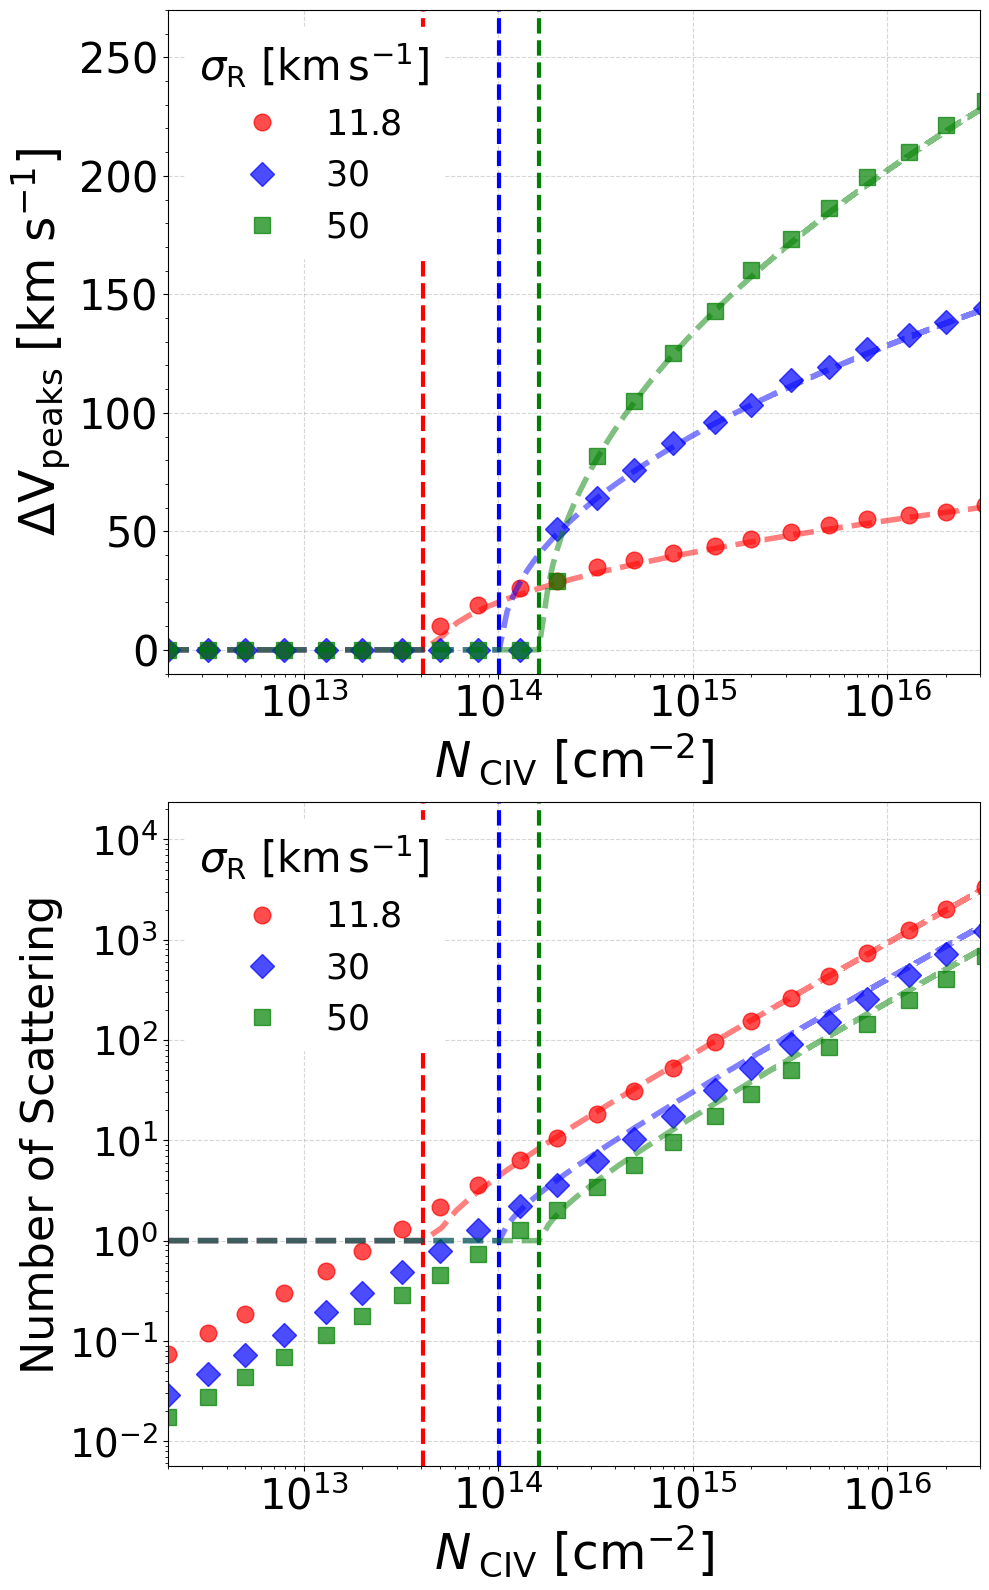

In [9]:
rr = np.arange(12, 17, 1)
atom_N = [13,20,32,50,79]
total_N_c = np.outer(10**rr, atom_N) / 10
total_N_c = total_N_c.flatten()



rand_nn = [11.8 , 30 , 50]
color = ['r','b','g']

fig = plt.figure(1,figsize=(10,16))

plt.subplot(211)

shape= np.array(['o','D','s'])

for kk , rand in enumerate(rand_nn):

    vv = []
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            a , lam = del_v_peaks('k',atom,index,0,1,rand)
            vv.append(a)

    column_density,N_o_Scat,Del_V = N_esc_scat(rand*1e5)
    plt.plot(column_density,Del_V ,linestyle='--',alpha=0.5,color = color[kk],lw=4)
    plt.plot(total_N_c, vv,marker=shape[kk],linestyle='',markersize=12,alpha=0.7,color = color[kk],label = r'${}$'.format(rand))

    tt = np.where(Del_V  == 0)[0][-1]

    plt.axvline(x=column_density[tt], ymin=0 ,ymax=1, linestyle = '--',alpha=1,lw=3,color=color[kk])

    plt.xscale('log')

plt.xlabel(r'${N} \, _{\mathrm{C IV}}$ [cm$^{-2}$]',fontsize =35)
plt.xscale('log')
plt.xlim(2*10**12,3*10**16)
plt.ylim(-10,270)
plt.ylabel(r'$\Delta \mathrm{V}_{\mathrm{peaks}}$ [km s$^{-1}$]',fontsize =35)
plt.minorticks_on()
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(True,linestyle='--',alpha=0.5)
leg = plt.legend(
    fontsize=25,
    title=r'$\sigma_{\rm R} ~ [\rm km\,s^{-1}]$',
    loc='upper left',
    title_fontsize=30,
    frameon=True
)
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(1)
leg.get_frame().set_edgecolor('white') 
plt.tight_layout()


plt.subplot(212)
for kk , rand in enumerate(rand_nn):

    vv = []
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            a = data_scat('k',atom,index,0,1,rand)
            vv.append(a)

    column_density,N_o_Scat,Del_V = N_esc_scat(rand*1e5)
    plt.plot(column_density,N_o_Scat,linestyle='--',alpha=0.5,color = color[kk],lw=4)
    plt.plot(total_N_c, vv,marker=shape[kk],linestyle='',markersize=12,alpha=0.7,color = color[kk],label = r'${}$'.format(rand))
    plt.xscale('log')
    tt = np.where(Del_V  == 0)[0][-1]
    plt.axvline(x=column_density[tt], ymin=0 ,ymax=1,alpha=1,linestyle = '--',lw=3, color=color[kk])



plt.xlabel(r'${N} \, _{\mathrm{C IV}}$ [cm$^{-2}$]',fontsize =35)
plt.xscale('log')
plt.yscale('log')
plt.xlim(2*10**12,3*10**16)
plt.xticks(fontsize=30)
plt.yticks(fontsize=28)
# plt.ylim(scat.min(),scat.max()+2)
plt.ylabel(r'Number of Scattering',fontsize =32)
plt.minorticks_on()
plt.grid(True,linestyle='--',alpha=0.5)
leg = plt.legend(
    fontsize=25,
    title=r'$\sigma_{\rm R} ~ [\rm km\,s^{-1}]$',
    loc='upper left',
    title_fontsize=30,
    frameon=True
)
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(1)
leg.get_frame().set_edgecolor('white') 

plt.tight_layout()



# plt.savefig('/home/jin/바탕화면/simulation_vs_analyvic_jin_halo_mono.pdf',bbox_inches="tight")
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/simulation_vs_analyvic_jin_halo_mono.pdf',bbox_inches="tight")

(-1.0, 1.0)

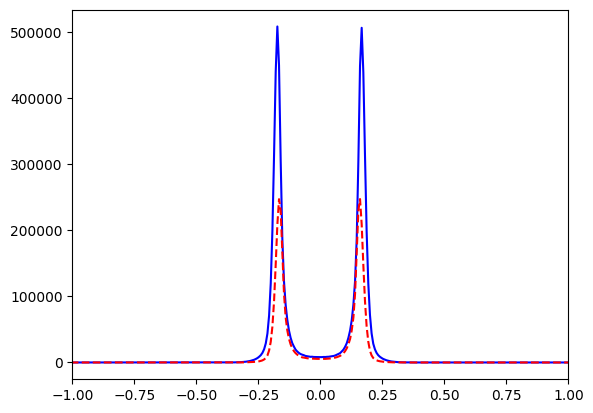

In [50]:
lam, spec_tot , spec_halo, x = K_H_from_Combine_data_x('k',79,16,0,1,11.8)
plt.plot(x,spec_tot,'b-')
lam, spec_tot , spec_halo, x = K_H_from_Combine_data_x('h',79,16,0,1,11.8)
plt.plot(x,spec_tot,'r--')
plt.xlim(-1,1)

In [55]:
def calculate_x(lam, C_IV_K_A, c_c_k):
    # lam: 주어진 lambda 값 (스칼라 또는 배열)
    # C_IV_K_A, c_c_k: 상수값 또는 변수
    # 반환값: x
    
    x = ((lam - C_IV_K_A) * c_c_k) / (11.8 * lam)
    return x

lam_value = 1549


x_value = calculate_x(lam_value, C_IV_K_A, cc_k)
print(f"x = {x_value}")

x = 13.334533397929256


[1548.0717 1548.2976] [344665. 348896.]


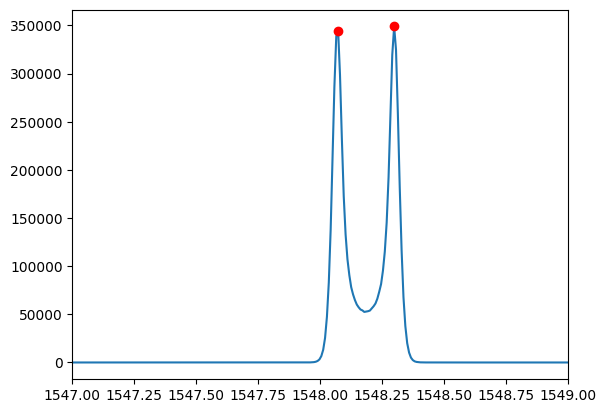

In [10]:
lam, spec_tot , spec_halo = K_H_from_Combine_data('k',13,15,0,1,11.8)
plt.plot(lam,spec_halo)
plt.xlim(1547,1549)

peaks, _ = find_peaks(spec_halo, height=0.5) 




# print(lam[peaks])
tt = np.argsort(spec_halo[peaks])[-2:]
aa = peaks[tt]
peak_lam = lam[aa]
peak_val = spec_halo[aa]
print(peak_lam, peak_val)
plt.plot(peak_lam, peak_val,'ro')
FWHM_k = FWHM('k',13,16,0,1,50)
# print(FWHM_k)

In [11]:
atom, index = 79,12
rand = 11.8
tau_0('k',atom,index,0,1,rand)

0.2372543562971028

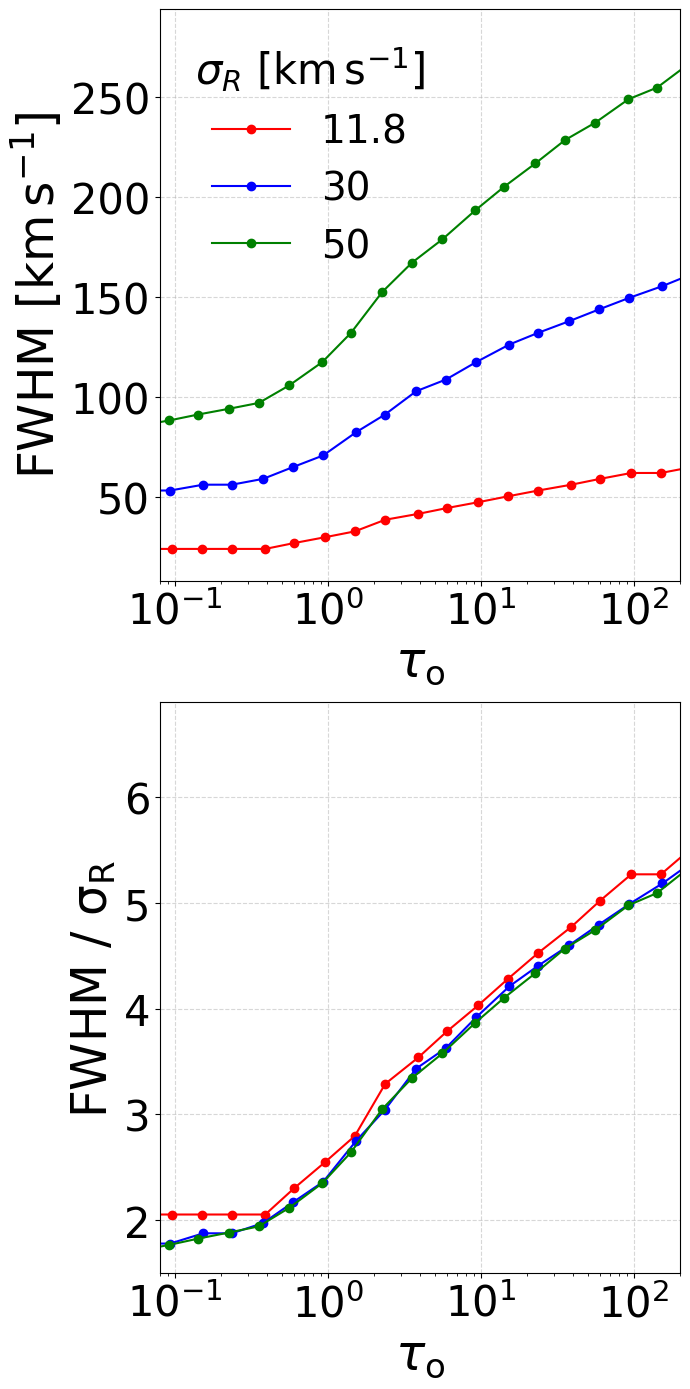

In [12]:
rr = np.arange(12, 17, 1)
atom_N = [13,20,32,50,79]
total_N_c = np.outer(10**rr, atom_N) / 10
total_N_c = total_N_c.flatten()



rand_nn = [11.8 , 30 , 50]
color = ['r','b','g']

fig = plt.figure(1,figsize=(7,14))


plt.subplot(211)

for kk , rand in enumerate(rand_nn):

    vv = np.array([])
    tau_K = np.array([])
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            a = FWHM('k',atom,index,0,1,rand)
            vv = np.append(a,vv)
            b= tau_0('k',atom,index,0,1,rand)
            tau_K = np.append(b,tau_K) 
    
    plt.plot(tau_K/ (rand / 11.8) , vv ,'-o',color = color[kk],label=rf'{rand}')

    plt.xscale('log')

plt.xscale('log')
plt.xlabel(r'$\tau_{\rm o}$',fontsize=35)
plt.ylabel(r'$ \rm {FWHM} ~[\rm km \, s^{-1}]$',fontsize=35)
plt.xlim(0.08,2e2)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
# plt.ylim(1.5,6.9)
plt.grid(True,linestyle='--',alpha=0.5)
plt.legend(loc='upper left',fontsize = 28,ncol=1,title = r'$\sigma_R ~ [\rm km \, s^{-1}]$',title_fontsize=30,frameon=False)

                
plt.subplot(212)

for kk , rand in enumerate(rand_nn):

    vv = np.array([])
    tau_K = np.array([])
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            a = FWHM('k',atom,index,0,1,rand)
            vv = np.append(a,vv)
            b= tau_0('k',atom,index,0,1,rand)
            tau_K = np.append(b,tau_K) 
    
    plt.plot(tau_K/ (rand / 11.8) , vv / rand ,'-o',color = color[kk],label=rf'{rand}')

    plt.xscale('log')

plt.xscale('log')
plt.xlabel(r'$\tau_{\rm o}$',fontsize=35)
plt.ylabel(r'$ \rm {FWHM} ~/~ {\sigma_R}$',fontsize=35)
plt.xlim(0.08,2e2)
plt.xticks(fontsize=30)
plt.yticks([2,3,4,5,6],fontsize=30)
plt.ylim(1.5,6.9)
plt.grid(True,linestyle='--',alpha=0.5)
# plt.legend(loc='upper left',fontsize = 25,ncol=1,title = r'$\sigma_R ~ [\rm km \, s^{-1}]$',title_fontsize=30,frameon=False)

plt.tight_layout()


# plt.savefig('/home/jin/바탕화면/FWHM_ratio.pdf',bbox_inches="tight")
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/FWHM_ratio.pdf',bbox_inches="tight")

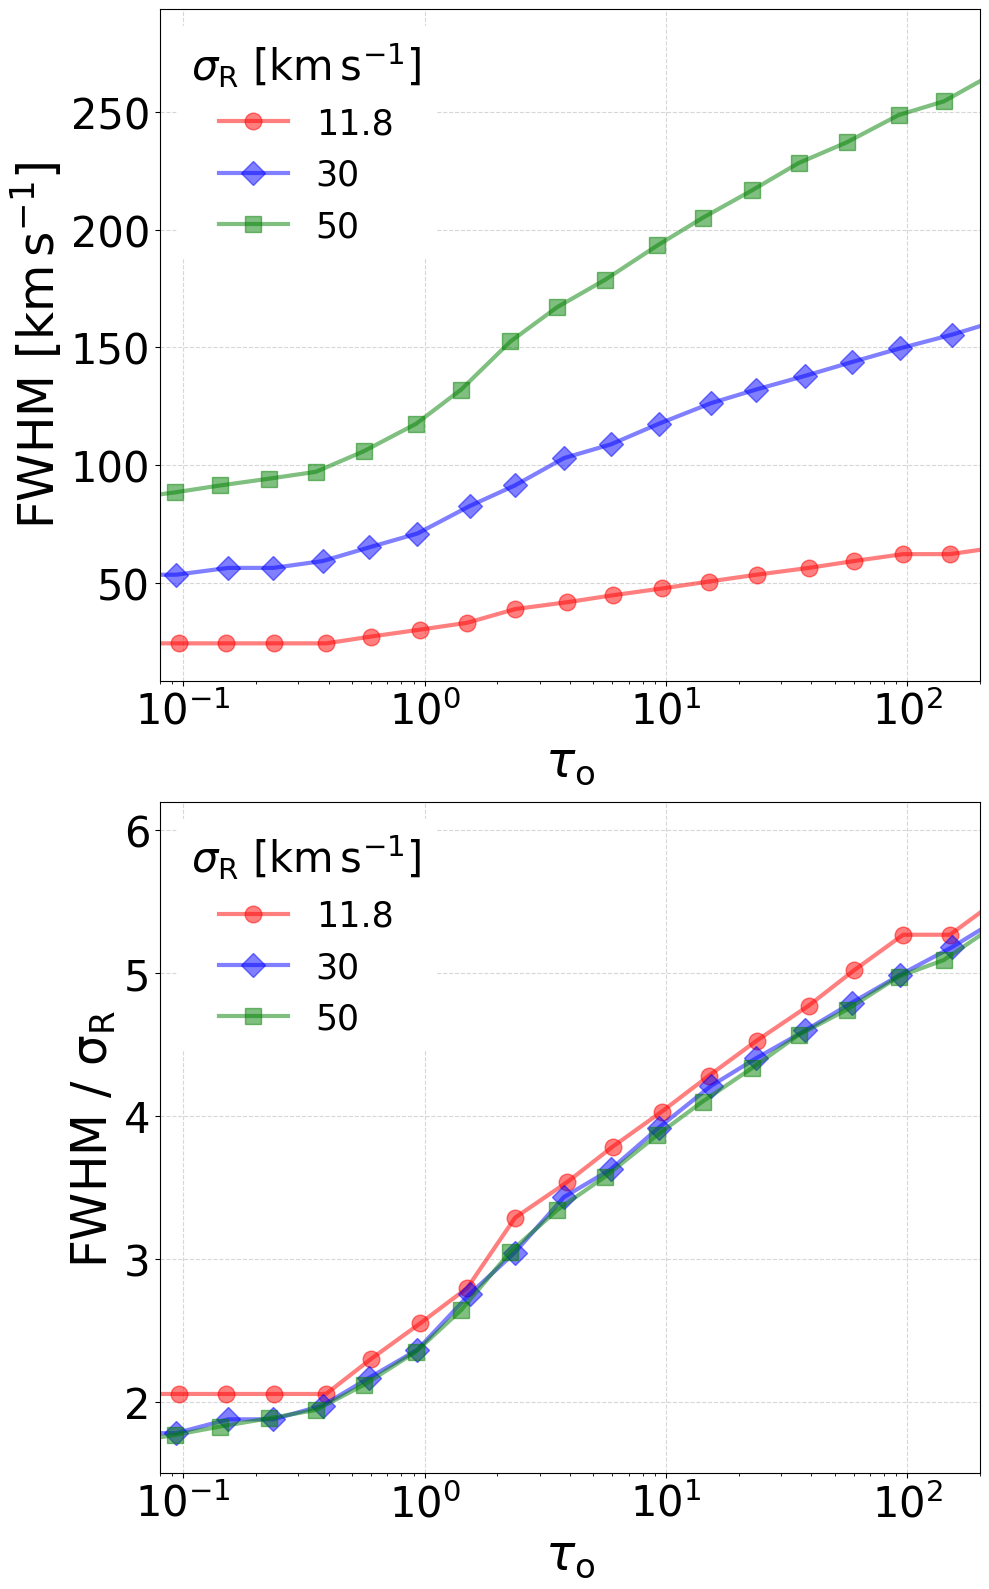

In [13]:
rr = np.arange(12, 17, 1)
atom_N = [13,20,32,50,79]
total_N_c = np.outer(10**rr, atom_N) / 10
total_N_c = total_N_c.flatten()



rand_nn = [11.8 , 30 , 50]
color = ['r','b','g']

fig = plt.figure(1,figsize=(10,16))


plt.subplot(211)
shape= np.array(['o','D','s'])

for kk , rand in enumerate(rand_nn):

    vv = np.array([])
    tau_K = np.array([])
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            a = FWHM('k',atom,index,0,1,rand)
            vv = np.append(a,vv)
            b= tau_0('k',atom,index,0,1,rand)
            tau_K = np.append(b,tau_K) 
    
    plt.plot(tau_K/ (rand / 11.8) , vv ,marker=shape[kk],linestyle='-',markersize=12,color = color[kk],alpha=0.5,lw=3,label=rf'{rand}')

    plt.xscale('log')

plt.xscale('log')
plt.xlabel(r'$\tau_{\rm o}$',fontsize=35)
plt.ylabel(r'$ \rm {FWHM} ~[\rm km \, s^{-1}]$',fontsize=35)
plt.xlim(0.08,2e2)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
# plt.ylim(1.5,6.9)
plt.grid(True,linestyle='--',alpha=0.5)
# plt.legend(loc='upper left',fontsize = 28,ncol=1,title = r'$\sigma_R ~ [\rm km \, s^{-1}]$',title_fontsize=30,frameon=False)

leg = plt.legend(
    fontsize=25,
    title=r'$\sigma_{\rm R} ~ [\rm km\,s^{-1}]$',
    loc='upper left',
    title_fontsize=30,
    frameon=True
)
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(1)
leg.get_frame().set_edgecolor('white') 

                
plt.subplot(212)

shape= np.array(['o','D','s'])
for kk , rand in enumerate(rand_nn):

    vv = np.array([])
    tau_K = np.array([])
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            a = FWHM('k',atom,index,0,1,rand)
            vv = np.append(a,vv)
            b= tau_0('k',atom,index,0,1,rand)
            tau_K = np.append(b,tau_K) 
    
    # plt.plot(
    #     tau_K / (rand / 11.8),
    #     vv / rand,
    #     marker=shape[kk],
    #     linestyle='-',
    #     markersize=10,
    #     color=color[kk],
    #     markerfacecolor='none',  # Makes center transparent
    #     markeredgewidth=2,  
    #     alpha=0.5,
    #     lw=2,
    #     label=rf'{rand}'
    # )
    plt.plot(tau_K/ (rand / 11.8) , vv / rand ,marker=shape[kk],linestyle='-',markersize=12,color = color[kk],alpha=0.5,lw=3,label=rf'{rand}')

    plt.xscale('log')

plt.xscale('log')
plt.xlabel(r'$\tau_{\rm o}$',fontsize=35)
plt.ylabel(r'$ \rm {FWHM} ~/~ {\sigma_R}$',fontsize=35)
plt.xlim(0.08,2e2)
plt.xticks(fontsize=30)
plt.yticks([2,3,4,5,6],fontsize=30)
plt.ylim(1.5,6.2)
plt.grid(True,linestyle='--',alpha=0.5)
# plt.legend(loc='upper left',fontsize = 25,ncol=1,title = r'$\sigma_R ~ [\rm km \, s^{-1}]$',title_fontsize=30,frameon=False)

leg = plt.legend(
    fontsize=25,
    title=r'$\sigma_{\rm R} ~ [\rm km\,s^{-1}]$',
    loc='upper left',
    title_fontsize=30,
    frameon=True
)
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(1)
leg.get_frame().set_edgecolor('white') 


plt.tight_layout()


# plt.savefig('/home/jin/바탕화면/FWHM_ratio.pdf',bbox_inches="tight")
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/FWHM_ratio.pdf',bbox_inches="tight")

(-1500.0, 1500.0)

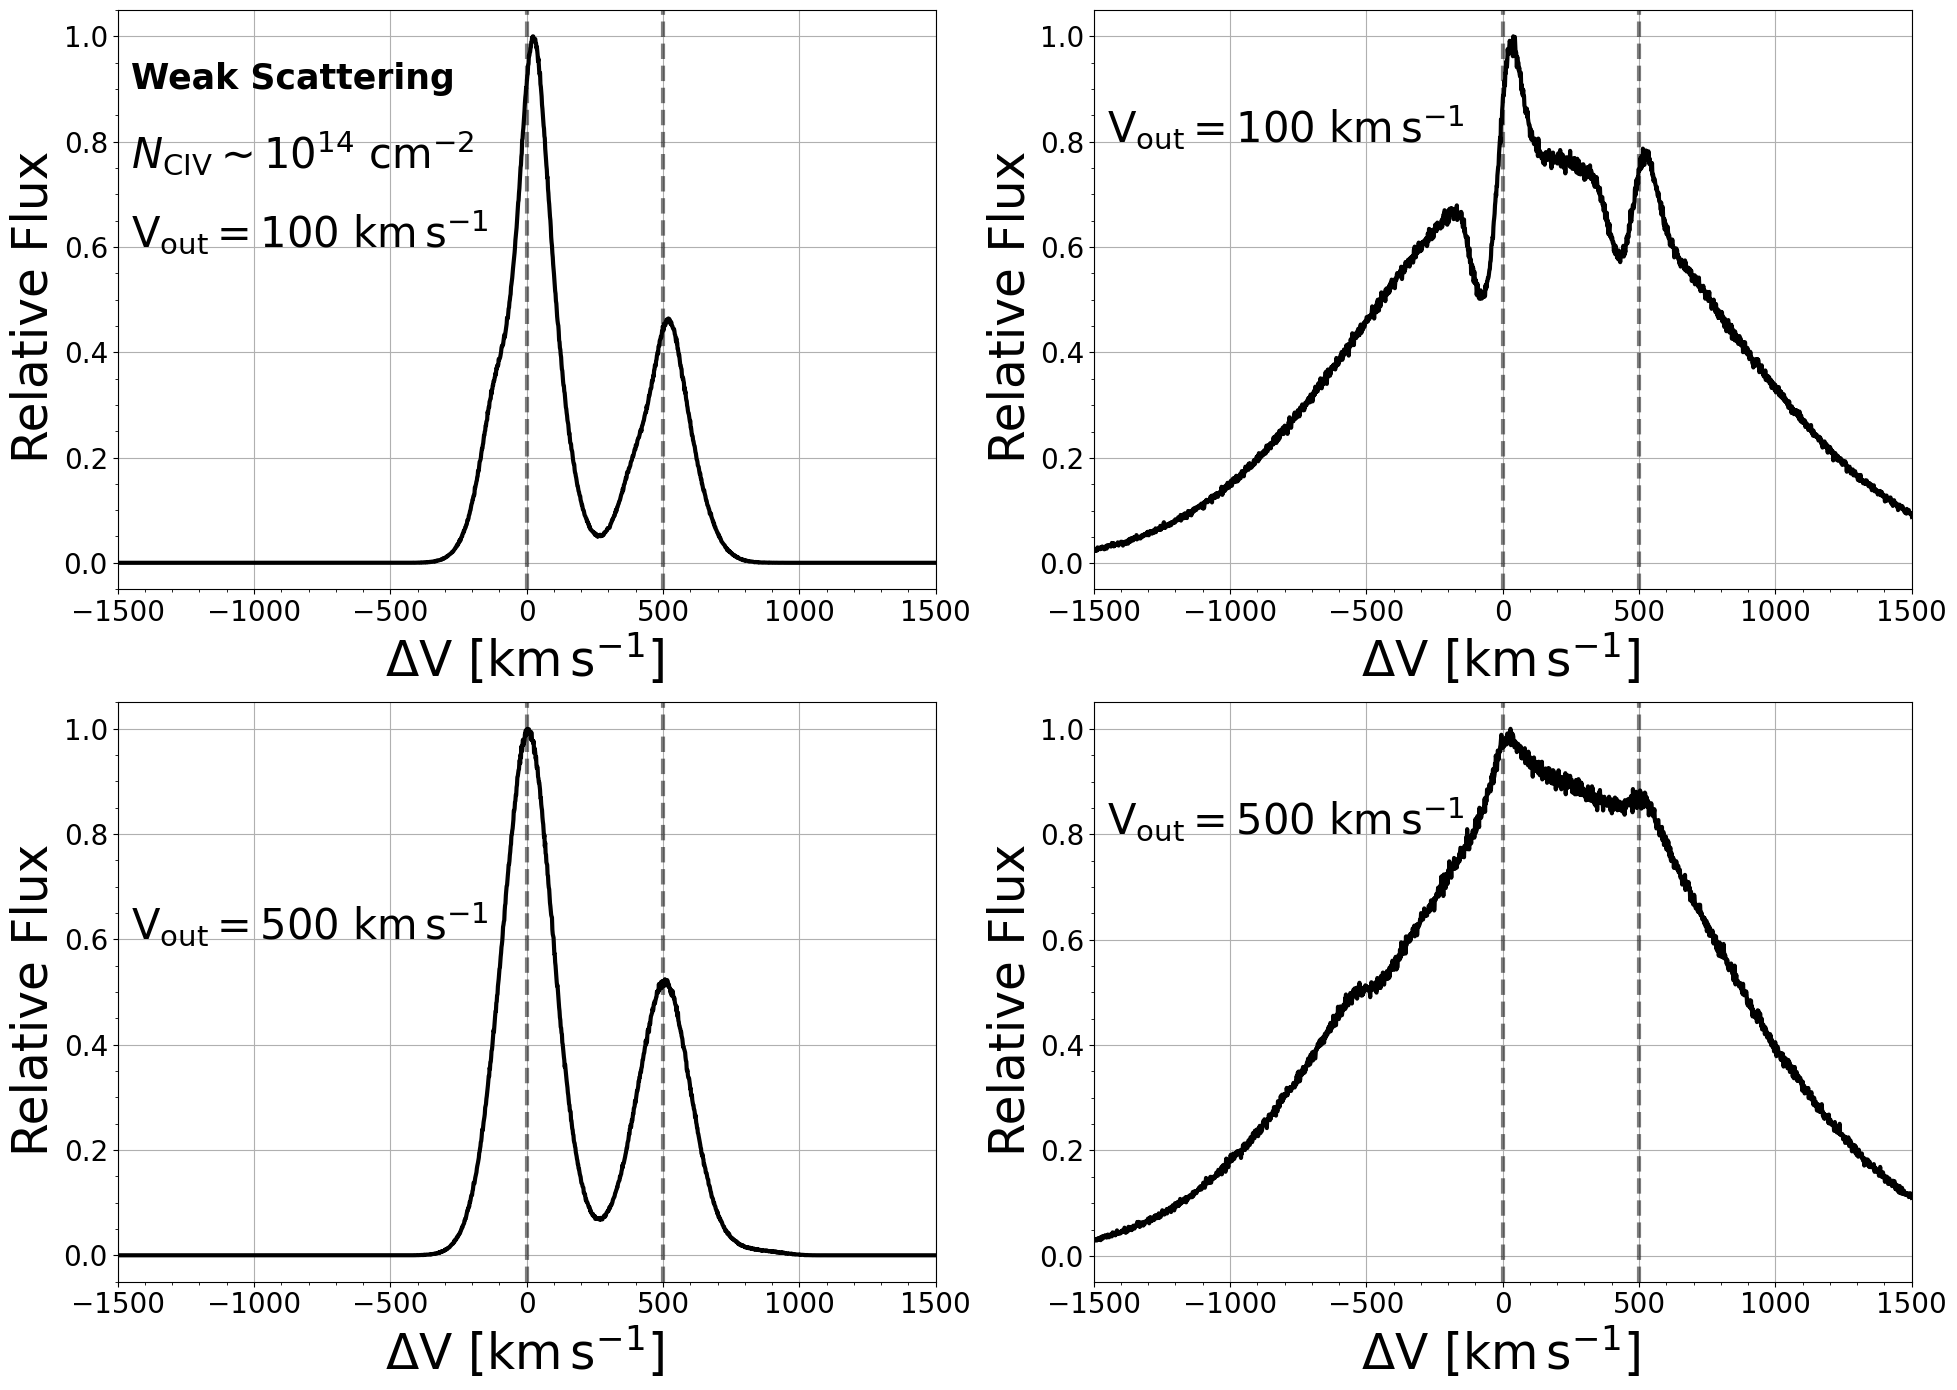

In [14]:
fig = plt.figure(1,figsize=(25,14))
index = 14
atom_num,vran = 10, 50

plt.subplot(221)
vout,vemit =  100, 100



normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(
    lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),
    K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,
    'k-', lw=3, alpha=1.0, label=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $'
)

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(loc='upper right',fontsize=20,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')

plt.text(-1450,0.9,s='Weak Scattering',fontweight='bold',size=25)
plt.text(-1450,0.75,s=f'$N_{{\\rm CIV}} \\sim 10^{{{index}}}~{{\\rm cm^{{-2}}}}$',fontweight='bold',size=30)
plt.text(-1450,0.6,s=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $',fontweight='bold',size=30)

plt.tight_layout()
plt.xlim(-1500,1500)

plt.subplot(222)
vout,vemit =  100, 600

normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(
    lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),
    K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,
    'k-', lw=3, alpha=1.0, label=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $'
)

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(fontsize=35,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.legend(loc='upper left',fontsize=20,frameon=False)
plt.text(-1450,0.8,s=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $',fontweight='bold',size=30)
plt.tight_layout()
plt.xlim(-1500,1500)


plt.subplot(223)
vout,vemit =  500, 100

normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(
    lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),
    K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,
    'k-', lw=3, alpha=1.0, label=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $'
)

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',title_fontsize=40,fontsize=35,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.legend(loc='upper right',fontsize=20,frameon=False)
plt.text(-1450,0.6,s=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $',fontweight='bold',size=30)
plt.tight_layout()
plt.xlim(-1500,1500)



plt.subplot(224)
vout,vemit =  500, 600

normal = K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1].max()
plt.plot(
    lam_to_vel(K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[0]),
    K_H_from_Combine_data('all',atom_num,index, vout,vemit,vran)[1]/normal,
    'k-', lw=3, alpha=1.0, label=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $'
)

plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)


plt.xlim(-300,1150)
plt.xticks(fontsize=20)
plt.xlabel(r'$\Delta \rm V ~[\rm km \, s^{-1}]$ ',fontsize=35)

# plt.xlim(-300,1050)
plt.yticks(fontsize=20)
plt.ylabel(r'Relative Flux ',fontsize=35)
# plt.legend(title=r'$N_{\rm CIV}~[\rm cm^{-2}]$',title_fontsize=40,fontsize=35,frameon=False)
plt.minorticks_on()
plt.grid(True, linestyle='-')
# plt.legend(loc='upper left',fontsize=20,frameon=False)
plt.text(-1450,0.8,s=f'$\\rm V_{{\\rm out}} = {vout}~{{\\rm km \\, s^{{-1}}}} $',fontweight='bold',size=30)
plt.xlim(-1500,1500)


# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RT_Scat_Mock_ws.pdf',bbox_inches="tight") 


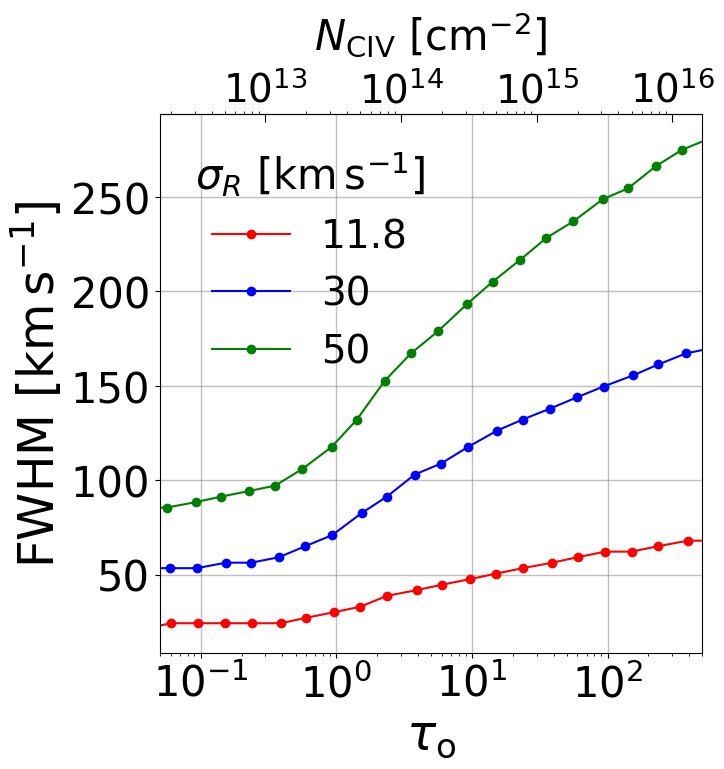

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, FuncFormatter
import math
# 기존 코드로 Figure 생성
fig, ax1 = plt.subplots(figsize=(7, 7)) 

rr = np.arange(12, 17, 1)
atom = [13,20,32,50,79]
rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * atom / 10
total_N_c = total_N_c.flatten()
vemit = 1



for kk, rand in enumerate(rand_nn):
    vv = np.array([])
    tau_K = np.array([])
    for ii, index in enumerate(rr):
        for jj, atom in enumerate(atom_N):
            a = FWHM('k',atom,index,0,1,rand)
            vv = np.append(a,vv)
            b = tau_0('k',atom,index,0,1,rand)
            tau_K = np.append(b,tau_K) 
    
    plt.plot(tau_K/(rand/11.8), vv, '-o', color=color[kk], label=rf'{rand}')
    plt.xscale('log')

# 축 설정
ax1.set_xlabel(r'$\tau_{\rm o}$', fontsize=35)
ax1.set_ylabel(r'$ \rm {FWHM} ~[\rm km \, s^{-1}]$', fontsize=35)
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30)
ax1.grid(True,linestyle='-',color='grey',alpha=0.5,lw=1)
ax1.legend(fontsize=28, title=r'$\sigma_R ~ [\rm km\, s^{-1}]$', title_fontsize=30,frameon=False)
ax1.set_xlim(0.05,500)

tao_K = np.zeros(len(total_N_c))
for ii, N_civ in enumerate(total_N_c):
    index = math.floor(math.log10(N_civ))
    atom_n = int(N_civ/ 10**index*10)
    tao_K[ii] = tau_0('k',atom_n,index,0,1,11.8)

def Nc_to_tauK(x):
    return np.interp(x, total_N_c, tao_K)

def tauK_to_Nc(x):
    return np.interp(x, tao_K, total_N_c)

secax = ax1.secondary_xaxis('top', functions=(tauK_to_Nc,Nc_to_tauK))
# secax.set_xlabel(r'$\overline{\tau_{\rm 0,K}}$', fontsize=28)
secax.tick_params(axis='x', labelsize=28)
secax.set_xlabel(r'${N_{\rm CIV}}~[{\rm cm^{-2}}]$', fontsize=30, labelpad=15)
secax.tick_params(axis='x', which='major', direction='in', length=6)
secax.spines['top'].set_linestyle('--')

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/FWHM_ratio_1.pdf',bbox_inches="tight")

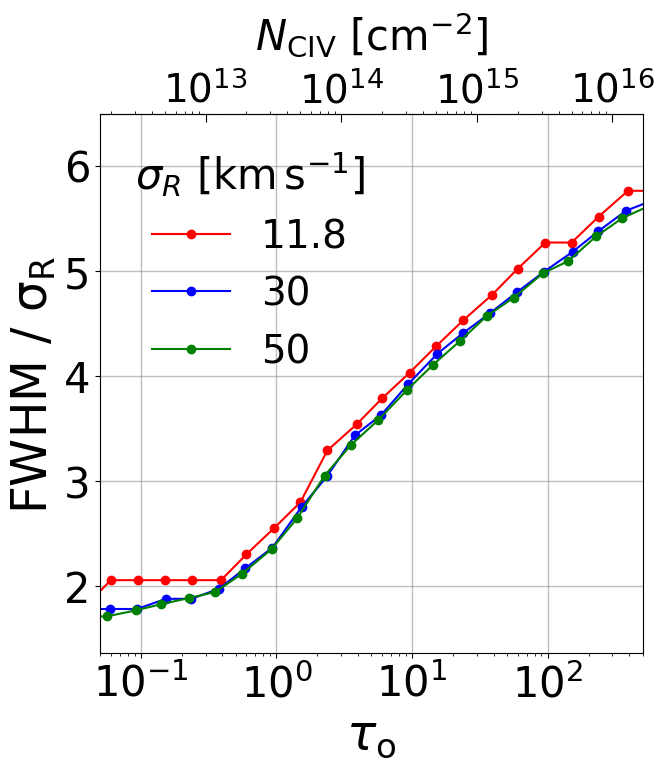

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, FuncFormatter
import math
# 기존 코드로 Figure 생성
fig, ax1 = plt.subplots(figsize=(7, 7)) 

rr = np.arange(12, 17, 1)
atom = [13,20,32,50,79]
rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * atom / 10
total_N_c = total_N_c.flatten()
vemit = 1



for kk , rand in enumerate(rand_nn):

    vv = np.array([])
    tau_K = np.array([])
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            a = FWHM('k',atom,index,0,1,rand)
            vv = np.append(a,vv)
            b= tau_0('k',atom,index,0,1,rand)
            tau_K = np.append(b,tau_K) 
    
    plt.plot(tau_K/ (rand / 11.8) , vv / rand ,'-o',color = color[kk],label=rf'{rand}')

    plt.xscale('log')

# 축 설정
ax1.set_xlabel(r'$\tau_{\rm o}$', fontsize=35)
ax1.set_ylabel(r'$ \rm {FWHM}~/~\sigma_{\rm R}$', fontsize=35)
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30)
ax1.grid(True,linestyle='-',color='grey',alpha=0.5,lw=1)
ax1.legend(fontsize=28, title=r'$\sigma_R ~ [\rm km\, s^{-1}]$', title_fontsize=30,frameon=False)
ax1.set_xlim(0.05,500)

tao_K = np.zeros(len(total_N_c))
for ii, N_civ in enumerate(total_N_c):
    index = math.floor(math.log10(N_civ))
    atom_n = int(N_civ/ 10**index*10)
    tao_K[ii] = tau_0('k',atom_n,index,0,1,11.8)

def Nc_to_tauK(x):
    return np.interp(x, total_N_c, tao_K)

def tauK_to_Nc(x):
    return np.interp(x, tao_K, total_N_c)

secax = ax1.secondary_xaxis('top', functions=(tauK_to_Nc,Nc_to_tauK))
# secax.set_xlabel(r'$\overline{\tau_{\rm 0,K}}$', fontsize=28)
secax.tick_params(axis='x', labelsize=28)
secax.set_xlabel(r'${N_{\rm CIV}}~[{\rm cm^{-2}}]$', fontsize=30, labelpad=15)
secax.tick_params(axis='x', which='major', direction='in', length=6)
secax.spines['top'].set_linestyle('--')

# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/FWHM_ratio_2.pdf',bbox_inches="tight")


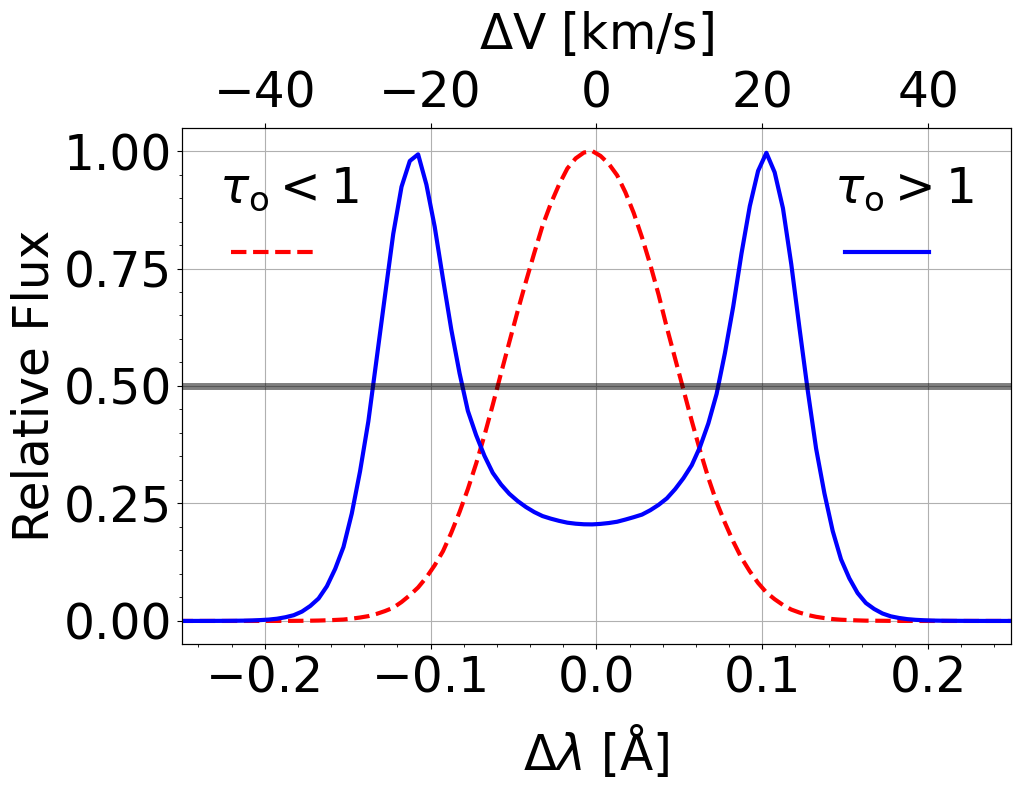

In [17]:
# fig= plt.figure(1,figsize=(18, 10))
lw_s = 3
atom= 79
v_ran = 11.8

fig, ax1 = plt.subplots(1, 1, figsize=(10, 8))

indices = [12, 14]
color = ['r', 'b']
tau_lesser_handles = []  # tau < 1 (N_CIV = 12)
tau_lesser_labels = []
tau_greater_handles = []  # tau > 1 (N_CIV = 13, 14, 15, 16)
tau_greater_labels = []

# 첫 번째 x축
for ii, index in enumerate(indices):
    # x, y = K_H_from_Combine_data('k',atom,index,0,1,rand)
    normal = (K_H_from_Combine_data('k',atom,index,0,1,v_ran )[2]).max()
    xx = np.arange(K_H_from_Combine_data('k',atom,index,0,1,v_ran )[0].min(),K_H_from_Combine_data('k',atom,index,0,1,v_ran )[0].max(),0.005)
    yy = np.interp(xx, K_H_from_Combine_data('k',atom,index,0,1,v_ran )[0], K_H_from_Combine_data('k',atom,index,0,1,v_ran )[2])
    line_s = '--' if index == 12 else '-'
    # yy = np.interp(xx, )
    plot_handle, = ax1.plot(
        # ((globals()[f'halo_x_K_{atom}_{index}_{v_ran}'] - C_IV_K_A)),
        # globals()[f'halo_y_K_{atom}_{index}_{v_ran}'] / normal,
        xx-C_IV_K_A, 
        yy/normal,

        lw=lw_s,
        color=color[ii],
        label=f'',
        linestyle=line_s
    )
    
    # Legend 그룹화 (tau < 1 vs tau > 1)
    if index == 12:
        tau_lesser_handles.append(plot_handle)
        tau_lesser_labels.append(f'')
    else:
        tau_greater_handles.append(plot_handle)
        tau_greater_labels.append(f'')

# 새 x축 추가 (y축 공유)


ax1.axhline(xmin=0,xmax=1,y=0.5,lw=5 , alpha=0.5, color='k')
ax2 = plt.gca().twiny()
ax1.set_xlim(-0.25, 0.25)
ax2.set_xlim(-50, 50)
ax1.set_xlabel(r'$\Delta \lambda $ $\rm [\AA]$', fontsize=35, labelpad=15)
ax2.set_xlabel(r'$\Delta \rm V $ [km/s]', fontsize=35, labelpad=15)
ax1.set_ylabel('Relative Flux', fontsize=35)
ax1.tick_params(axis='x', labelsize=35)
ax2.tick_params(axis='x', labelsize=35)
ax1.tick_params(axis='y', labelsize=35)
ax1.minorticks_on()
ax1.grid(True)

# ✅ "log{N_{CIV}}"를 최상단 title로 추가 (빈 핸들 사용)
logN_legend = ax1.legend(
    handles=[plt.Line2D([], [], linestyle="")],  # 빈 핸들 (타이틀만 추가
    loc='upper right',
    fontsize=35,
    title_fontsize=35,
    frameon=False
)

# 첫 번째 legend (tau < 1)
legend1 = ax1.legend(
    handles=tau_lesser_handles,
    labels=tau_lesser_labels,
    loc='upper left',
    fontsize=30,
    title=r'$\tau_{\rm o} < 1$',
    title_fontsize=35,
    frameon=False
    # bbox_to_anchor=(0.95, 0.88) 
)

# 두 번째 legend (tau > 1), 바로 아래 배치 (bbox_to_anchor 사용)
legend2 = ax1.legend(
    handles=tau_greater_handles,
    labels=tau_greater_labels,
    loc='upper right',
    fontsize=30,
    title=r'$\tau_{\rm o} > 1$',
    title_fontsize=35,
    frameon=False
    # bbox_to_anchor=(0.95, 0.7)  # ✅ 바로 아래 배치 (숫자 조정 가능)
)

# ✅ 첫 번째 title 유지
ax1.add_artist(logN_legend)
ax1.add_artist(legend1)



plt.tight_layout()


# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/FWHM_ex.png',bbox_inches="tight")


In [18]:
print(tau_0('K',79,13,0,0,0))
print(tau_0('H',79,13,0,0,0))

2.372543562971028
1.1887691957623256


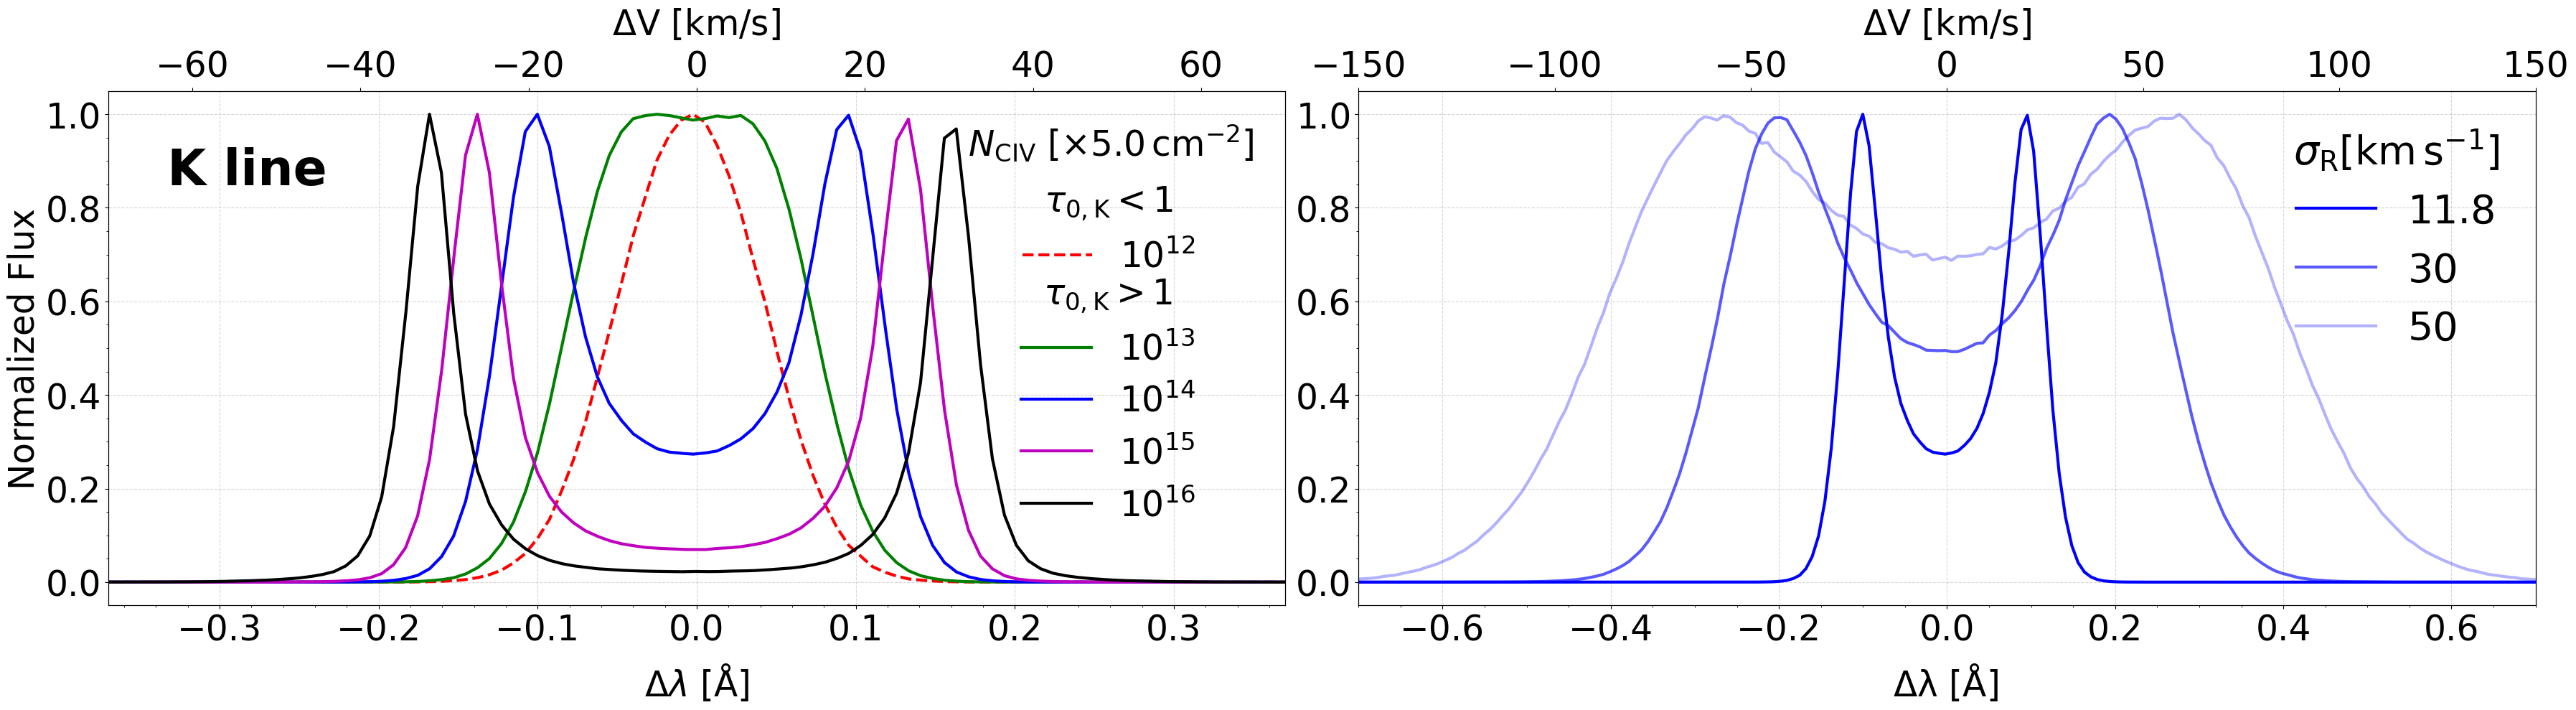

In [19]:
fig= plt.figure(1,figsize=(36, 10))
lw_s = 3
atom= 50
v_ran = 11.8
ax1 = plt.subplot(121)

indices = [12, 13, 14, 15, 16]
color = ['r', 'g', 'b', 'm', 'k']
tau_lesser_handles = []  # tau < 1 (N_CIV = 12)
tau_lesser_labels = []
tau_greater_handles = []  # tau > 1 (N_CIV = 13, 14, 15, 16)
tau_greater_labels = []

# 첫 번째 x축
for ii, index in enumerate(indices):
    # x, y = K_H_from_Combine_data('k',atom,index,0,1,rand)
    normal = (K_H_from_Combine_data('k',atom,index,0,1,v_ran )[2]).max()
    xx = np.arange(K_H_from_Combine_data('k',atom,index,0,1,v_ran )[0].min(),K_H_from_Combine_data('k',atom,index,0,1,v_ran )[0].max(),0.00005)
    yy = np.interp(xx, K_H_from_Combine_data('k',atom,index,0,1,v_ran )[0], K_H_from_Combine_data('k',atom,index,0,1,v_ran )[2])
    line_s = '--' if index == 12 else '-'
    # yy = np.interp(xx, )
    plot_handle, = ax1.plot(
        # ((globals()[f'halo_x_K_{atom}_{index}_{v_ran}'] - C_IV_K_A)),
        # globals()[f'halo_y_K_{atom}_{index}_{v_ran}'] / normal,
        xx-C_IV_K_A, 
        yy/normal,

        lw=lw_s,
        color=color[ii],
        label=f'$10^{{{index}}}$',
        linestyle=line_s
    )
    
    # Legend 그룹화 (tau < 1 vs tau > 1)
    if index == 12:
        tau_lesser_handles.append(plot_handle)
        tau_lesser_labels.append(f'$10^{{{index}}}$')
    else:
        tau_greater_handles.append(plot_handle)
        tau_greater_labels.append(f'$10^{{{index}}}$')

# 새 x축 추가 (y축 공유)
ax2 = plt.gca().twiny()
ax1.set_xlim(-0.37, 0.37)
ax2.set_xlim(-70, 70)
ax1.set_xlabel(r'$\Delta \lambda $ $\rm [\AA]$', fontsize=35, labelpad=15)
ax2.set_xlabel(r'$\Delta \rm V $ [km/s]', fontsize=35, labelpad=15)
ax1.set_ylabel('Normalized Flux', fontsize=35)
ax1.tick_params(axis='x', labelsize=35)
ax2.tick_params(axis='x', labelsize=35)
ax1.tick_params(axis='y', labelsize=35)
ax1.minorticks_on()
ax1.grid(True,linestyle='--',alpha=0.5)

# ✅ "log{N_{CIV}}"를 최상단 title로 추가 (빈 핸들 사용)
logN_legend = ax1.legend(
    handles=[plt.Line2D([], [], linestyle="")],  # 빈 핸들 (타이틀만 추가)
    labels=[r'${N_{\rm C IV}} ~\rm [ \times 5.0 \, cm^{-2}]$'],
    loc='upper right',
    fontsize=35,
    title_fontsize=35,
    frameon=False
)

# 첫 번째 legend (tau < 1)
legend1 = ax1.legend(
    handles=tau_lesser_handles,
    labels=tau_lesser_labels,
    loc='upper right',
    fontsize=35,
    title=r'$\tau_{0,\rm K} < 1$',
    title_fontsize=35,
    frameon=False,
    bbox_to_anchor=(0.95, 0.88) 
)

# 두 번째 legend (tau > 1), 바로 아래 배치 (bbox_to_anchor 사용)
legend2 = ax1.legend(
    handles=tau_greater_handles,
    labels=tau_greater_labels,
    loc='upper right',
    fontsize=35,
    title=r'$\tau_{0,\rm K} > 1$',
    title_fontsize=35,
    frameon=False,
    bbox_to_anchor=(0.95, 0.7)  # ✅ 바로 아래 배치 (숫자 조정 가능)
)

# ✅ 첫 번째 title 유지
ax1.add_artist(logN_legend)
ax1.add_artist(legend1)

# 추가 텍스트
ax2.text(x=-65, y=0.85, s=' K line', size=50, fontweight='bold')

plt.tight_layout()



ax3 = plt.subplot(122)
index = 14
atom = 50
v_ran_list = [11.8, 30, 50]
colors = ['k', 'r', 'b']
line_s = ['-','--','dashdot']
# 첫 번째 x축 (K line)
for ii, v_ran in enumerate(v_ran_list):
    normal = K_H_from_Combine_data('k',atom,index,0,1,v_ran)[2].max()
    m = 1.0 - ii*0.35
    xx = np.arange(K_H_from_Combine_data('k',atom,index,0,1,v_ran)[0].min(),K_H_from_Combine_data('k',atom,index,0,1,v_ran)[0].max(),0.0001)
    yy = np.interp(xx, K_H_from_Combine_data('k',atom,index,0,1,v_ran)[0], K_H_from_Combine_data('k',atom,index,0,1,v_ran)[2])
    ax3.plot(
        ((xx - C_IV_K_A)),
        yy / normal,
        lw=lw_s,
        color='b',
        alpha = m,
        linestyle = '-',
        label=f'{v_ran}'
    )

# 새 x축 추가 (H line, y축 공유)
ax4 = ax3.twiny()

# for ii, v_ran in enumerate(v_ran_list):
#     normal = globals()[f'halo_y_K_{atom}_{index}_{v_ran}'].max()
#     ax4.plot(
#         ((globals()[f'halo_x_K_{atom}_{index}_{v_ran}'] / C_IV_K_A) - 1) * cc_k,
#         globals()[f'halo_y_K_{atom}_{index}_{v_ran}'] / normal,
#         linestyle='-',  # 동일한 스타일로 그리기
#         lw=lw_s,
#         color=colors[ii]
#     )

# 축 설정
ax3.set_xlim(-0.7, 0.7)
ax4.set_xlim(-150, 150)
ax3.set_xlabel(r'$\Delta \rm \lambda ~\rm [\AA] $ ', fontsize=35, labelpad=15)
ax4.set_xlabel(r'$\Delta \rm V $ [km/s]', fontsize=35, labelpad=15)
# ax3.set_ylabel('Relative Flux', fontsize=35)
ax3.tick_params(axis='x', labelsize=35)
ax4.tick_params(axis='x', labelsize=35)
ax3.tick_params(axis='y', labelsize=35)
ax3.minorticks_on()
ax3.grid(True,linestyle='--',alpha=0.5)

# 범례 설정
ax3.legend(
    loc='upper right',
    fontsize=35,
    title=r'$\sigma_R ~ [\rm km\,s^{-1}]$',
    title_fontsize=35,
    ncol=1
)
ax3.legend(loc='upper right', fontsize=40,title=r'$\sigma_{\rm R} [\rm km \, s^{-1}]$',title_fontsize=40,frameon=False)
plt.tight_layout()


# plt.savefig('/home/jin/바탕화면/Monochromatic_line_K.pdf',bbox_inches="tight")
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Monochromatic_line_K.pdf',bbox_inches="tight")

In [20]:
print(np.log10(5*10**(13)))

13.698970004336019


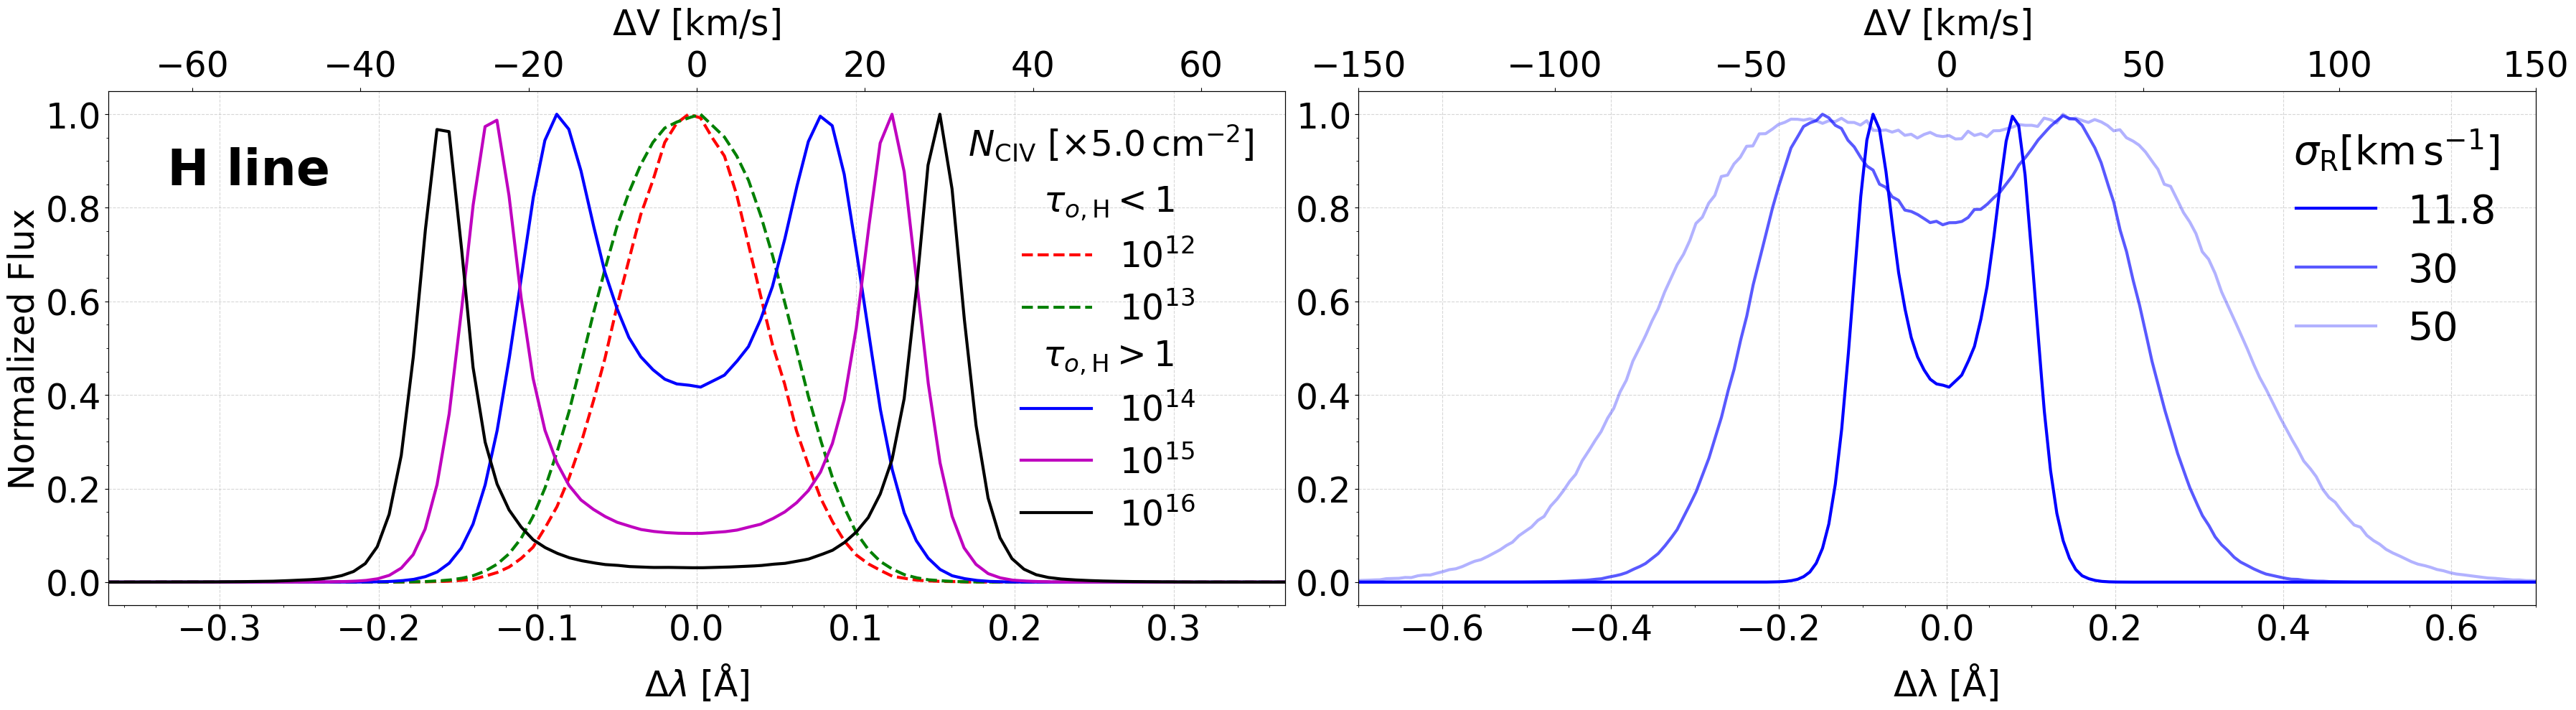

In [21]:
fig= plt.figure(1,figsize=(36, 10))
lw_s = 3
atom= 50
v_ran = 11.8
ax1 = plt.subplot(121)

indices = [12, 13, 14, 15, 16]
color = ['r', 'g', 'b', 'm', 'k']
tau_lesser_handles = []  # tau < 1 (N_CIV = 12)
tau_lesser_labels = []
tau_greater_handles = []  # tau > 1 (N_CIV = 13, 14, 15, 16)
tau_greater_labels = []

# 첫 번째 x축
for ii, index in enumerate(indices):
    # x, y = K_H_from_Combine_data('k',atom,index,0,1,rand)
    normal = (K_H_from_Combine_data('h',atom,index,0,1,v_ran )[2]).max()
    xx = np.arange(K_H_from_Combine_data('h',atom,index,0,1,v_ran )[0].min(),K_H_from_Combine_data('h',atom,index,0,1,v_ran )[0].max(),0.00005)
    yy = np.interp(xx, K_H_from_Combine_data('h',atom,index,0,1,v_ran )[0], K_H_from_Combine_data('h',atom,index,0,1,v_ran )[2])
    line_s = '--' if index == 12 or index == 13 else '-'
    # yy = np.interp(xx, )
    plot_handle, = ax1.plot(
        # ((globals()[f'halo_x_K_{atom}_{index}_{v_ran}'] - C_IV_K_A)),
        # globals()[f'halo_y_K_{atom}_{index}_{v_ran}'] / normal,
        xx-C_IV_H_A, 
        yy/normal,

        lw=lw_s,
        color=color[ii],
        label=f'$10^{{{index}}}$',
        linestyle=line_s
    )
    
    # Legend 그룹화 (tau < 1 vs tau > 1)
    if index == 12 or index == 13:
        tau_lesser_handles.append(plot_handle)
        tau_lesser_labels.append(f'$10^{{{index}}}$')
    else:
        tau_greater_handles.append(plot_handle)
        tau_greater_labels.append(f'$10^{{{index}}}$')

# 새 x축 추가 (y축 공유)
ax2 = plt.gca().twiny()
ax1.set_xlim(-0.37, 0.37)
ax2.set_xlim(-70, 70)
ax1.set_xlabel(r'$\Delta \lambda $ $\rm [\AA]$', fontsize=35, labelpad=15)
ax2.set_xlabel(r'$\Delta \rm V $ [km/s]', fontsize=35, labelpad=15)
ax1.set_ylabel('Normalized Flux', fontsize=35)
ax1.tick_params(axis='x', labelsize=35)
ax2.tick_params(axis='x', labelsize=35)
ax1.tick_params(axis='y', labelsize=35)
ax1.minorticks_on()
ax1.grid(True,linestyle='--',alpha=0.5)

# ✅ "log{N_{CIV}}"를 최상단 title로 추가 (빈 핸들 사용)
logN_legend = ax1.legend(
    handles=[plt.Line2D([], [], linestyle="")],  # 빈 핸들 (타이틀만 추가)
    labels=[r'${N_{\rm C IV}} ~\rm [\times 5.0 \, cm^{-2}$]'],
    loc='upper right',
    fontsize=35,
    title_fontsize=35,
    frameon=False
)

# 첫 번째 legend (tau < 1)
legend1 = ax1.legend(
    handles=tau_lesser_handles,
    labels=tau_lesser_labels,
    loc='upper right',
    fontsize=35,
    title=r'$\tau_{o,\rm H} < 1$',
    title_fontsize=35,
    frameon=False,
    bbox_to_anchor=(0.95, 0.88) 
)

# 두 번째 legend (tau > 1), 바로 아래 배치 (bbox_to_anchor 사용)
legend2 = ax1.legend(
    handles=tau_greater_handles,
    labels=tau_greater_labels,
    loc='upper right',
    fontsize=35,
    title=r'$\tau_{o,\rm H} > 1$',
    title_fontsize=35,
    frameon=False,
    bbox_to_anchor=(0.95, 0.58)  # ✅ 바로 아래 배치 (숫자 조정 가능)
)

# ✅ 첫 번째 title 유지
ax1.add_artist(logN_legend)
ax1.add_artist(legend1)

# 추가 텍스트
ax2.text(x=-65, y=0.85, s=' H line', size=50, fontweight='bold')

plt.tight_layout()



ax3 = plt.subplot(122)
index = 14
atom = 50
v_ran_list = [11.8, 30, 50]
colors = ['k', 'r', 'b']
line_s = ['-','--','dashdot']
# 첫 번째 x축 (K line)
for ii, v_ran in enumerate(v_ran_list):
    normal = K_H_from_Combine_data('H',atom,index,0,1,v_ran)[2].max()
    m = 1.0 - ii*0.35
    xx = np.arange(K_H_from_Combine_data('H',atom,index,0,1,v_ran)[0].min(),K_H_from_Combine_data('H',atom,index,0,1,v_ran)[0].max(),0.0001)
    yy = np.interp(xx, K_H_from_Combine_data('H',atom,index,0,1,v_ran)[0], K_H_from_Combine_data('H',atom,index,0,1,v_ran)[2])
    ax3.plot(
        ((xx - C_IV_H_A)),
        yy / normal,
        lw=lw_s,
        color='b',
        alpha = m,
        linestyle = '-',
        label=f'{v_ran}'
    )

# 새 x축 추가 (H line, y축 공유)
ax4 = ax3.twiny()

# for ii, v_ran in enumerate(v_ran_list):
#     normal = globals()[f'halo_y_K_{atom}_{index}_{v_ran}'].max()
#     ax4.plot(
#         ((globals()[f'halo_x_K_{atom}_{index}_{v_ran}'] / C_IV_K_A) - 1) * cc_k,
#         globals()[f'halo_y_K_{atom}_{index}_{v_ran}'] / normal,
#         linestyle='-',  # 동일한 스타일로 그리기
#         lw=lw_s,
#         color=colors[ii]
#     )

# 축 설정
ax3.set_xlim(-0.7, 0.7)
ax4.set_xlim(-150, 150)
ax3.set_xlabel(r'$\Delta \rm \lambda ~\rm [\AA] $ ', fontsize=35, labelpad=15)
ax4.set_xlabel(r'$\Delta \rm V $ [km/s]', fontsize=35, labelpad=15)
# ax3.set_ylabel('Relative Flux', fontsize=35)
ax3.tick_params(axis='x', labelsize=35)
ax4.tick_params(axis='x', labelsize=35)
ax3.tick_params(axis='y', labelsize=35)
ax3.minorticks_on()
ax3.grid(True,linestyle='--',alpha=0.5)

# 범례 설정
ax3.legend(
    loc='upper right',
    fontsize=35,
    title=r'$\sigma_R ~ [\rm km\,s^{-1}]$',
    title_fontsize=35,
    ncol=1
)
ax3.legend(loc='upper right', fontsize=40,title=r'$\sigma_{\rm R} [\rm km \, s^{-1}]$',title_fontsize=40,frameon=False)
plt.tight_layout()


# plt.savefig('/home/jin/바탕화면/Monochromatic_line_K.pdf',bbox_inches="tight")
# plt.savefig('/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Monochromatic_line_H.pdf',bbox_inches="tight")